In [11]:
import numpy as np
from time import sleep

from orchid.instrument import InstrumentAdapter
from orchid.parameter import DataKind, Parameter, Readout
from orchid.context import ExperimentContext
from orchid.procedure import ErrorPolicy, MonitorProcedure, Procedure, Sweep, WriteMode
from orchid.runner import ExperimentRunner

In [2]:
from eeroqlab.instruments import MagnetController, KoradKA3305P, BlueFors, Vulcan, QDac2Eeroq
from pymeasure.instruments.yokogawa.yokogawa7651 import Yokogawa7651
from pymeasure.instruments.srs.sr830 import SR830
from eeroqlab.instruments import E5071

In [3]:
vulcan  = Vulcan()
yoko    = Yokogawa7651('GPIB0::19::INSTR')
korad   = KoradKA3305P(resourceName='COM9', includeSCPI=False)
bf      = BlueFors("bf_fridge","B://", 1, 2, 3, 4, 5, 6, 1, 2, 3, 5, 6, 7, 8)
lockin  = SR830(name="lockin", adapter='GPIB0::8::INSTR')
qdac    = QDac2Eeroq(name="qdac", address="TCPIP::10.103.204.39::5025::SOCKET", timeout=60)
vna     = E5071(name="E5071C", address="e5071c.eeroq.local")

Connected to: QDevil QDAC-II (serial:86, firmware:13-1.57) in 0.05s


In [4]:
qdac.close()

In [18]:
# gate names to qdac channel mapping
gates = {
    "local_in":    9,         # reservoir 1 of LOCAL ST 
    "local_out":   13,        # reservoir 2 of LOCAL ST 
    "local_gate":  11,        # central gate of LOCAL ST
    "local_top":   15,        # top filament electrode of LOCAL ST
    "remote_gate": 3,         # this is central gate of the REMOTE ST
    "remote_top":  17,        # top filament electrode of REMOTE ST
    "connect":     7,         # this is the channel connecting LOCAL and REMOTE devices
}
qdac.setup_gates(gates)
qdac.snapshot()

╭────────────┬─────────────┬──────────────┬─────────────┬───────────────┬──────────────┬───────────╮
│   local_in │   local_out │   local_gate │   local_top │   remote_gate │   remote_top │   connect │
├────────────┼─────────────┼──────────────┼─────────────┼───────────────┼──────────────┼───────────┤
│          1 │           1 │            1 │           0 │             0 │            0 │         0 │
╰────────────┴─────────────┴──────────────┴─────────────┴───────────────┴──────────────┴───────────╯


In [5]:
ctx = ExperimentContext(
    data_root="./example_data",
    metadata={
        "sample": "chip_A1",
        "operator": "Niyaz",
        "fridge": "BlueFors_1",
        "cooldown": 42,
    },
)

In [6]:
ctx.add_instrument("lockin", lockin, backend="pymeasure")
ctx.add_instrument("qdac", qdac, backend="qcodes")
ctx.add_instrument("vna", vna, backend="custom")
ctx.add_instrument("vulcan", vulcan, backend="custom")
ctx.add_instrument("bluefors", bf, backend="qcodes")

InstrumentAdapter('bluefors', backend='qcodes')

In [7]:
ctx.add_parameter("T6", get_func=lambda: bf.get_temperature(6), unit="K")
ctx.add_parameter("Vch", get_func=lambda: qdac.local_gate.dc_constant_V(), set_func=lambda x: qdac.local_gate.ramp_V(x), unit="V")

def set_Vr(x):
    qdac.local_in.ramp_V(x)
    qdac.local_out.ramp_V(x)

ctx.add_parameter("Vr", get_func=qdac.local_in.dc_constant_V, set_func=set_Vr, unit="V")
ctx.add_parameter("tau_flash", get_func=lambda: vulcan.get_duration(), set_func=lambda x: vulcan.set_duration(x), unit="s")
ctx.add_parameter("fac", instrument="lockin", attr="frequency", unit="Hz")
ctx.add_parameter("Vac", instrument="lockin", attr="sine_voltage", unit="Vrms")

Parameter('Vac', sine_voltage, unit='Vrms')

In [8]:
ctx.snapshot()

Name       Type           Value  Unit
---------  ------  ------------  ------
T6         param       0.664685  K
Vch        param       1         V
Vr         param       1         V
tau_flash  param     100         s
fac        param   34730         Hz
Vac        param       1         Vrms


In [9]:
ctx.add_readout("Vx", kind="scalar", get_func=lambda: lockin.x, unit="V")
ctx.add_readout("Vy", kind="scalar", get_func=lambda: lockin.y, unit="V")
ctx.add_readout("S21", kind="image", shape=(1601,3),
    get_func=vna.take_one_averaged_trace,
    unit=["Hz","dB","deg"],
    contains=["f","mag","phase"],)

Readout('S21', image, shape=(1601, 3))

In [10]:
ctx

ExperimentContext(5 instruments, 6 parameters, 3 readouts)

In [ ]:
proc1 = Procedure(
    name="Vch_sweep",
    context=ctx,
    sweeps=[
        Sweep("Vch", np.linspace(0, 1, 101)),
    ],
    readouts=["Vx", "Vy"],
    settle_time=0.01,          # 10ms settle after each set
    tags=["transport", "1d"],
    metadata={"field": "0T"},
    write_mode=WriteMode.SWEEPWISE
)

In [ ]:
runner = ExperimentRunner()

runner.run(proc1)

Vch_sweep: 100%|██████████| 101/101 [00:10<00:00,  9.33pt/s]

Experiment 'Vch_sweep' completed. Data saved to: example_data\0001


In [25]:
def hook_init_sweep(index):
    ctx["Vch"] = 0.1
    sleep(2)

In [24]:
ctx["Vch"] = 0.2

In [20]:
ctx["Vr"] = 0.5

In [21]:
ctx.snapshot()

Name       Type    Value        Unit
---------  ------  -----------  -------------------
T6         param   0.664087     K
Vch        param   0.6          V
Vr         param   0.5          V
tau_flash  param   100          s
fac        param   34730.0      Hz
Vac        param   1.0          Vrms
Vx         scalar  1.43052e-06  V
Vy         scalar  6.43733e-06  V
S21        image   [[...]]      ['Hz', 'dB', 'deg']


In [22]:
vulcan.flash()

In [26]:
proc2 = Procedure(
    name="Vch_sweep",
    context=ctx,
    sweeps=[
        Sweep("Vr", np.linspace(0.5, 0.6, 5)),
        Sweep("Vch", np.linspace(0.1, 1, 41)),
    ],
    readouts=["Vx", "Vy"],
    settle_time=0.6,          # 10ms settle after each set
    tags=["transport", "1d"],
    metadata={"field": "0T"},
    write_mode=WriteMode.SWEEPWISE,
    before_sweep=hook_init_sweep
)

In [27]:
runner = ExperimentRunner()
runner.run(proc2)

Vch_sweep: 100%|██████████| 205/205 [02:41<00:00,  1.27pt/s]

Experiment 'Vch_sweep' completed. Data saved to: example_data\0004


WindowsPath('example_data/0004')

In [28]:
import zarr
import matplotlib.pyplot as plt

['Vx', 'Vy', 'Vch']


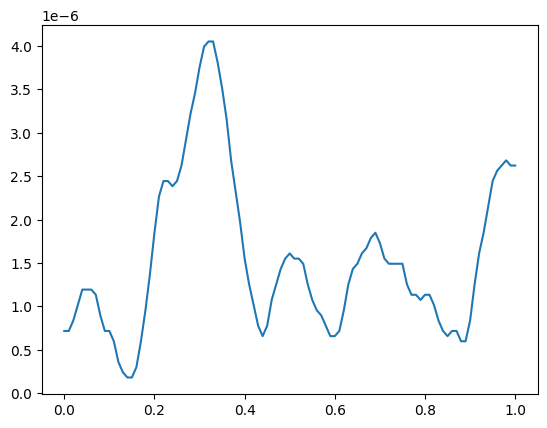

In [29]:


# Open vault
z = zarr.open("./example_data/0001/vault.zarr", mode="r")

# List arrays
print(list(z.keys()))    # ['Vgt', 'lockin_X']

# Read arrays (standard NumPy indexing)
vgt = z["Vch"][:]          # control values, shape (101,)
signal = z["Vx"][:]  # measured data, shape (101,)
plt.plot(vgt, signal)
plt.show()



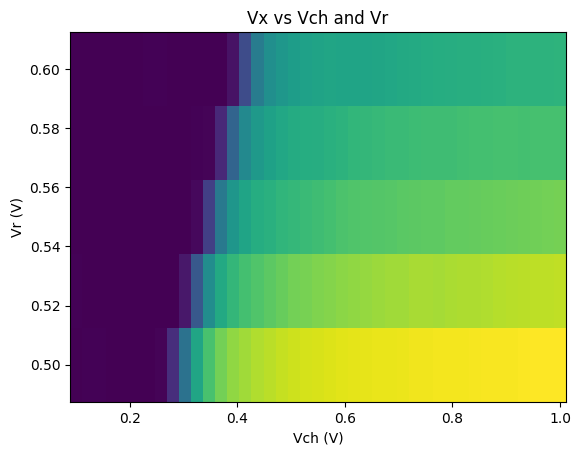

In [30]:
# For 2D: shape is (outer_len, inner_len)
z = zarr.open("./example_data/0004/vault.zarr", mode="r")
data_2d = z["Vx"][:]  # shape (50, 101)
Vch = z["Vch"][:]  # shape (101)
Vr = z["Vr"][:]  # shape (50)

plt.pcolormesh(Vch, Vr, data_2d)
plt.xlabel("Vch (V)")
plt.ylabel("Vr (V)")
plt.title("Vx vs Vch and Vr")
plt.show()
